In [1]:
import os
import pandas as pd
import requests
import time
import json
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.formula.api as smf
import seaborn as sns 

from sklearn.cross_decomposition import PLSRegression
from pygam import LinearGAM, s
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.multitest import multipletests
from scipy.stats import gaussian_kde 
from sklearn.decomposition import FactorAnalysis

# Fetch data

In [ ]:
data_folder = os.path.join(os.path.expanduser("~/Desktop/Trading"), "Data")
os.makedirs(data_folder, exist_ok=True)

tickers_csv_file = os.path.join(data_folder, "russell3000_approx.csv")

API_KEY = "YwnbHRjcJvf6Md2OPoKbSRGHlzZ7hjR6"

if os.path.exists(tickers_csv_file):
    print("Loading Russell 3000 approximation from CSV cache...")
    df_r3000 = pd.read_csv(tickers_csv_file)
else:
    print("Fetching all stocks from FMP...")

    # Broad stock universe from FMP
    url = f"https://financialmodelingprep.com/stable/stock-list?apikey={API_KEY}"
    response = requests.get(url)
    response.raise_for_status()
    df = pd.DataFrame(response.json())

    print("Columns returned:")
    print(df.columns)

    # Keep likely U.S. common stocks
    if "exchangeShortName" in df.columns:
        df = df[df["exchangeShortName"].isin(["NYSE", "NASDAQ", "AMEX"])]

    if "type" in df.columns:
        df = df[df["type"].astype(str).str.lower() == "stock"]

    if "country" in df.columns:
        df = df[df["country"].astype(str).str.upper().isin(["US", "USA"])]

    if "name" in df.columns:
        bad_words = r"ETF|ETN|Fund|Trust|Preferred|Warrant|Unit|Units"
        df = df[~df["name"].astype(str).str.contains(bad_words, case=False, na=False)]

    df = df.drop_duplicates(subset=["symbol"]).reset_index(drop=True)

    # If marketCap is already present, use it.
    # If not, you'll need a second pass to pull market cap another way.
    if "marketCap" in df.columns:
        df_r3000 = (
            df.sort_values("marketCap", ascending=False)
              .head(3000)
              .reset_index(drop=True)
        )
    else:
        print("No marketCap column returned from stock-list.")
        print("This means you can only build a broad U.S. universe here, not top-3000 by cap.")
        df_r3000 = df.copy()

    df_r3000.to_csv(tickers_csv_file, index=False)
    print(f"Saved {len(df_r3000)} rows to {tickers_csv_file}")

print(df_r3000.shape)
print(df_r3000.columns)
print(df_r3000.head())

In [ ]:
API_KEY = "YwnbHRjcJvf6Md2OPoKbSRGHlzZ7hjR6"

data_folder = os.path.join(os.path.expanduser("~/Desktop/Trading"), "Data")
os.makedirs(data_folder, exist_ok=True)

tickers_csv_file = os.path.join(data_folder, "russell3000_approx.csv")

# input universe
df_tickers = pd.read_csv(tickers_csv_file)
tickers = df_tickers["symbol"].dropna().astype(str).unique().tolist()

# output files
snapshot_file = os.path.join(data_folder, "stock_snapshot_with_proxies.json")
estimates_file = os.path.join(data_folder, "analyst_estimates_12q.json")


def first_not_none(d, keys, default=None):
    """
    Return the first non-null value found in dictionary d for any key in keys.
    """
    for k in keys:
        if k in d and pd.notna(d[k]):
            return d[k]
    return default


def safe_get_json(url, sleep_time=0.15):
    """
    Small helper for FMP requests.
    """
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    out = r.json()
    time.sleep(sleep_time)
    return out


def fetch_snapshot_and_estimates(tickers, snapshot_file, estimates_file, force_refresh=False):
    """
    Returns:
        snapshot_df: one latest row per symbol with current/grouping proxies
        estimates_df: up to 12 quarterly analyst-estimate rows per symbol
    """

    if (
        not force_refresh
        and os.path.exists(snapshot_file)
        and os.path.exists(estimates_file)
    ):
        print("Loading both datasets from cache...")
        snapshot_df = pd.DataFrame(json.load(open(snapshot_file)))
        estimates_df = pd.DataFrame(json.load(open(estimates_file)))
        return snapshot_df, estimates_df

    snapshot_records = []
    estimate_records = []

    for i, ticker in enumerate(tickers, start=1):
        try:
            print(f"[{i}/{len(tickers)}] {ticker}")

            # -----------------------------
            # 1) Current quote
            # -----------------------------
            quote_url = f"https://financialmodelingprep.com/api/v3/quote/{ticker}?apikey={API_KEY}"
            quote_data = safe_get_json(quote_url)

            if not quote_data:
                continue

            quote_row = quote_data[0]
            price = quote_row.get("price")
            quote_date = quote_row.get("date")

            # -----------------------------
            # 2) Latest income statement
            # -----------------------------
            income_url = f"https://financialmodelingprep.com/api/v3/income-statement/{ticker}?limit=1&apikey={API_KEY}"
            income_data = safe_get_json(income_url)

            income_row = income_data[0] if income_data else {}
            eps = income_row.get("eps")
            report_date = income_row.get("date")
            revenue = income_row.get("revenue")
            net_income = income_row.get("netIncome")

            # -----------------------------
            # 3) Key metrics / valuation proxies
            # Docs show: /stable/key-metrics?symbol=AAPL
            # -----------------------------
            metrics_url = f"https://financialmodelingprep.com/stable/key-metrics?symbol={ticker}&apikey={API_KEY}"
            metrics_data = safe_get_json(metrics_url)
            metrics_row = metrics_data[0] if metrics_data else {}

            pe_ratio = first_not_none(
                metrics_row,
                ["peRatio", "priceEarningsRatio", "pToERatio"]
            )

            ps_ratio = first_not_none(
                metrics_row,
                ["priceToSalesRatio", "pToSRatio", "priceToSales"]
            )

            pb_ratio = first_not_none(
                metrics_row,
                ["pbRatio", "priceToBookRatio", "pToBRatio"]
            )

            roe = first_not_none(
                metrics_row,
                ["roe", "returnOnEquity"]
            )

            market_cap = first_not_none(
                quote_row,
                ["marketCap"]
            )

            # -----------------------------
            # 4) Analyst estimates: last 12 quarters
            # Docs show:
            # /stable/analyst-estimates?symbol=AAPL&period=annual&page=0&limit=10
            # so use period=quarter and limit=12
            # -----------------------------
            estimates_url = (
                f"https://financialmodelingprep.com/stable/analyst-estimates"
                f"?symbol={ticker}&period=quarter&page=0&limit=12&apikey={API_KEY}"
            )
            estimates_data = safe_get_json(estimates_url)

            if isinstance(estimates_data, list) and len(estimates_data) > 0:
                df_est = pd.DataFrame(estimates_data).copy()

                # normalize sort order
                if "date" in df_est.columns:
                    df_est["date"] = pd.to_datetime(df_est["date"], errors="coerce")
                    df_est = df_est.sort_values("date").tail(12)

                # choose the estimate columns if they exist
                keep_cols = [
                    "date",
                    "symbol",
                    "estimatedRevenueAvg",
                    "estimatedRevenueLow",
                    "estimatedRevenueHigh",
                    "estimatedEbitdaAvg",
                    "estimatedNetIncomeAvg",
                    "estimatedSgaExpenseAvg",
                    "estimatedEpsAvg",
                    "estimatedEpsLow",
                    "estimatedEpsHigh",
                    "numberAnalystsEstimatedRevenue",
                    "numberAnalystsEstimatedEps",
                ]

                existing_keep_cols = [c for c in keep_cols if c in df_est.columns]
                df_est = df_est[existing_keep_cols].copy()

                if "symbol" not in df_est.columns:
                    df_est["symbol"] = ticker

                # forward-growth proxies from the estimate panel itself
                df_est = df_est.sort_values("date").reset_index(drop=True)

                if "estimatedRevenueAvg" in df_est.columns and len(df_est) >= 2:
                    first_rev = df_est["estimatedRevenueAvg"].iloc[0]
                    last_rev = df_est["estimatedRevenueAvg"].iloc[-1]
                    if pd.notna(first_rev) and pd.notna(last_rev) and first_rev not in [0, None]:
                        rev_growth_12q = (last_rev / first_rev) - 1
                    else:
                        rev_growth_12q = None
                else:
                    rev_growth_12q = None

                if "estimatedEpsAvg" in df_est.columns and len(df_est) >= 2:
                    first_eps_est = df_est["estimatedEpsAvg"].iloc[0]
                    last_eps_est = df_est["estimatedEpsAvg"].iloc[-1]
                    if pd.notna(first_eps_est) and pd.notna(last_eps_est) and first_eps_est not in [0, None]:
                        eps_growth_12q = (last_eps_est / first_eps_est) - 1
                    else:
                        eps_growth_12q = None
                else:
                    eps_growth_12q = None

                # attach per-row firm snapshot info to each estimate row
                df_est["current_price"] = price
                df_est["current_eps_actual"] = eps
                df_est["latest_actual_report_date"] = report_date
                df_est["pe_ratio"] = pe_ratio
                df_est["ps_ratio"] = ps_ratio
                df_est["pb_ratio"] = pb_ratio
                df_est["roe"] = roe
                df_est["market_cap"] = market_cap
                df_est["expected_revenue_growth_12q"] = rev_growth_12q
                df_est["expected_eps_growth_12q"] = eps_growth_12q

                estimate_records.extend(df_est.to_dict(orient="records"))
            else:
                rev_growth_12q = None
                eps_growth_12q = None

            # -----------------------------
            # 5) One latest snapshot row per ticker
            # this preserves your old fields and adds grouping proxies
            # -----------------------------
            snapshot_records.append({
                "symbol": ticker,
                "price": price,
                "eps": eps,
                "date": report_date,         # preserve your old meaning: latest actual report date
                "quote_date": quote_date,    # optional current market date
                "revenue": revenue,
                "net_income": net_income,
                "pe_ratio": pe_ratio,
                "ps_ratio": ps_ratio,
                "pb_ratio": pb_ratio,
                "roe": roe,
                "market_cap": market_cap,
                "expected_revenue_growth_12q": rev_growth_12q,
                "expected_eps_growth_12q": eps_growth_12q
            })

        except Exception as e:
            print(f"Error fetching {ticker}: {e}")

    # save
    with open(snapshot_file, "w") as f:
        json.dump(snapshot_records, f, indent=2, default=str)

    with open(estimates_file, "w") as f:
        json.dump(estimate_records, f, indent=2, default=str)

    print(f"Saved {len(snapshot_records)} snapshot rows to {snapshot_file}")
    print(f"Saved {len(estimate_records)} estimate rows to {estimates_file}")

    snapshot_df = pd.DataFrame(snapshot_records)
    estimates_df = pd.DataFrame(estimate_records)

    return snapshot_df, estimates_df


snapshot_df, analyst_estimates_df = fetch_snapshot_and_estimates(
    tickers=tickers,
    snapshot_file=snapshot_file,
    estimates_file=estimates_file,
    force_refresh=False
)

print("\nSNAPSHOT COLUMNS")
print(snapshot_df.columns.tolist())
print(snapshot_df.head(10))

print("\nESTIMATES COLUMNS")
print(analyst_estimates_df.columns.tolist())
print(analyst_estimates_df.head(15))

In [5]:
#CLEANS AND TAKES LOG OF THE PE DATA

# Only keep rows with positive EPS
pe_data = price_earnings_df[price_earnings_df["eps"] > 0].copy()

# Compute log(PE)
pe_data["log_PE"] = np.log(pe_data["price"] / pe_data["eps"])

# Print row count for reference
print(pe_data.shape)

(480, 7)


In [6]:
# FETCHES INCOME STATEMENT AND BS STATEMENT AND CF STATEMENT
def fetch_statement(endpoint, tickers, period, limit, data_folder):
    """Fetch statements with unique JSON filename based on endpoint, period, limit."""
    output_file = os.path.join(
        data_folder,
        f"{endpoint}_{period}_limit{limit}.json"
    )

    if os.path.exists(output_file):
        print(f"Loading from cache: {output_file}")
        with open(output_file, "r") as f:
            return json.load(f)

    records = []
    for ticker in tickers:
        url = f"https://financialmodelingprep.com/api/v3/{endpoint}/{ticker}?period={period}&limit={limit}&apikey={API_KEY}"
        try:
            response = requests.get(url)
            response.raise_for_status()
            data = response.json()
            if data:
                for row in data:
                    row["symbol"] = ticker
                records.extend(data)
        except Exception as e:
            print(f"Error fetching {ticker} ({endpoint}): {e}")
        time.sleep(.2)  # API polite rate limit

    with open(output_file, "w") as f:
        json.dump(records, f, indent=2)
    print(f"Saved {len(records)} records to {output_file}")
    # "RECORDS HERE IS A LIST OF STRINGS NOT A DF"
    return records

# AT THIS POINT INCOME_DATA_2_YEARS IS STILL A LIST OF STRINGS STORED AS A VAR
income_data_2_years   = fetch_statement("income-statement", tickers, "annual", 2, data_folder)
balance_data_2_years  = fetch_statement("balance-sheet-statement", tickers, "annual", 2, data_folder)
cashflow_data_2_years = fetch_statement("cash-flow-statement", tickers, "annual", 2, data_folder)

# INCOME_DATA_2_YEARS IS CONVERTED TO A DF
income_data_2_years   = pd.DataFrame(income_data_2_years)
balance_data_2_years  = pd.DataFrame(balance_data_2_years)
cashflow_data_2_years = pd.DataFrame(cashflow_data_2_years)

print("Income shape:", income_data_2_years.shape)
print("Balance shape:", balance_data_2_years.shape)
print("Cash flow shape:", cashflow_data_2_years.shape)

Loading from cache: /Users/nicholassanso/Desktop/Trading/Data/income-statement_annual_limit2.json
Loading from cache: /Users/nicholassanso/Desktop/Trading/Data/balance-sheet-statement_annual_limit2.json
Loading from cache: /Users/nicholassanso/Desktop/Trading/Data/cash-flow-statement_annual_limit2.json
Income shape: (1006, 38)
Balance shape: (1006, 54)
Cash flow shape: (1006, 40)


# Preprocessing

In [7]:
cols_to_drop_income = [
    "netIncome", "netIncomeRatio", "epsdiluted", "eps",
    "operatingIncomeRatio", "incomeBeforeTaxRatio",
    "incomeBeforeTax", "operatingIncome","ebitda","ebitdaratio", "link", "finalLink","fillingDate","cik",
    "acceptedDate","reportedCurrency","period","calendarYear"]

cols_to_drop_balance = [
    "eps","retainedEarnings", "totalStockholdersEquity","othertotalStockholdersEquity", "totalEquity", 
    "link", "finalLink","fillingDate","cik","acceptedDate","reportedCurrency","period","calendarYear"]

cols_to_drop_cashflow = [
    "eps", "link", "finalLink","fillingDate","operatingCashFlow", "netCashProvidedByOperatingActivities",
    "cik","acceptedDate","netIncome","reportedCurrency","period","calendarYear"]

cols_to_drop_pe = ["eps","price","netIncome"]

income_data_2_years = income_data_2_years.drop(columns=cols_to_drop_income, errors="ignore")
balance_data_2_years = balance_data_2_years.drop(columns=cols_to_drop_balance, errors="ignore")
cashflow_data_2_years = cashflow_data_2_years.drop(columns=cols_to_drop_cashflow, errors="ignore")
pe_data = pe_data.drop(columns=cols_to_drop_pe, errors="ignore")

In [8]:
print(income_data_2_years.columns.tolist)
print(balance_data_2_years.columns.tolist)
print(cashflow_data_2_years.columns.tolist)
print(pe_data.columns.tolist)

<bound method IndexOpsMixin.tolist of Index(['date', 'symbol', 'revenue', 'costOfRevenue', 'grossProfit',
       'grossProfitRatio', 'researchAndDevelopmentExpenses',
       'generalAndAdministrativeExpenses', 'sellingAndMarketingExpenses',
       'sellingGeneralAndAdministrativeExpenses', 'otherExpenses',
       'operatingExpenses', 'costAndExpenses', 'interestIncome',
       'interestExpense', 'depreciationAndAmortization',
       'totalOtherIncomeExpensesNet', 'incomeTaxExpense',
       'weightedAverageShsOut', 'weightedAverageShsOutDil'],
      dtype='object')>
<bound method IndexOpsMixin.tolist of Index(['date', 'symbol', 'cashAndCashEquivalents', 'shortTermInvestments',
       'cashAndShortTermInvestments', 'netReceivables', 'inventory',
       'otherCurrentAssets', 'totalCurrentAssets', 'propertyPlantEquipmentNet',
       'goodwill', 'intangibleAssets', 'goodwillAndIntangibleAssets',
       'longTermInvestments', 'taxAssets', 'otherNonCurrentAssets',
       'totalNonCurrentAsset

In [9]:
# --- Clean up column names (remove spaces, tabs, and backslashes) ---
for df_name, df in {
    "income_data_2_years": income_data_2_years,
    "balance_data_2_years": balance_data_2_years,
    "cashflow_data_2_years": cashflow_data_2_years,
    "pe_data": pe_data
}.items():
    df.columns = df.columns.str.strip().str.replace(r'\\', '', regex=True)
    print(f"{df_name}: cleaned column names")


income_data_2_years: cleaned column names
balance_data_2_years: cleaned column names
cashflow_data_2_years: cleaned column names
pe_data: cleaned column names


In [10]:
def count_problematic_entries(df, label):
    print(f"\n🔍 Problematic value counts for {label} statement:")
    
    def count_issues(col):
        numeric_col = pd.to_numeric(col, errors='coerce')
        return ((numeric_col.isna()) | (numeric_col == 0)).sum()

    issue_counts = df.apply(count_issues)
    filtered_counts = issue_counts[issue_counts > 0].sort_values()
    print(filtered_counts)


In [11]:
count_problematic_entries(income_data_2_years, "Income")
count_problematic_entries(balance_data_2_years, "Balance Sheet")
count_problematic_entries(cashflow_data_2_years, "Cash Flow")


🔍 Problematic value counts for Income statement:
operatingExpenses                             8
depreciationAndAmortization                   9
incomeTaxExpense                             12
costOfRevenue                                20
interestExpense                              63
totalOtherIncomeExpensesNet                  65
sellingGeneralAndAdministrativeExpenses      79
otherExpenses                               330
interestIncome                              352
generalAndAdministrativeExpenses            548
researchAndDevelopmentExpenses              605
sellingAndMarketingExpenses                 727
date                                       1006
symbol                                     1006
dtype: int64

🔍 Problematic value counts for Balance Sheet statement:
totalNonCurrentAssets                         2
totalNonCurrentLiabilities                    4
totalDebt                                     5
totalCurrentAssets                            5
otherNonCurrentA

In [12]:
def sort_by_symbol_then_date(df):
    # Sort ascending by symbol, then by date (oldest first)
    return df.sort_values(["symbol", "date"], ascending=[True, True]).reset_index(drop=True)


income_sorted = sort_by_symbol_then_date(income_data_2_years)
balance_sorted = sort_by_symbol_then_date(balance_data_2_years)
cashflow_sorted = sort_by_symbol_then_date(cashflow_data_2_years)
pe_data_sorted = sort_by_symbol_then_date(pe_data)


pe_data_sorted.head(8)

,symbol,price_date,date,log_PE
0,A,None,2024-10-31,3.441659
1,AAPL,None,2024-09-28,3.739655
2,ABBV,None,2024-12-31,4.590733
3,ABNB,None,2024-12-31,3.367131
4,ABT,None,2024-12-31,2.852957
5,ACGL,None,2024-12-31,2.049800
6,ACN,None,2025-08-31,2.989775
7,ADBE,None,2024-11-29,3.341236


In [13]:
#DOUBLE CHECK THE ECISION TO ADD A CONSTANT... ELONGATING THE TAIL OF THE DISTRIBUTION
# DATA PROVIDER PUTS "0" FOR ANY LINE ITEM THAT DOESN'T EXIST IN THE FINANCIAL STATEMENT... ADDING THE CONSTANT THEN RETURNS A SMALL VALUE WHICH IN TURN 
#ALLOWS FOR A HUGE LOG CHANGE OUTLIER IF THAT LINE ITEM IN THE NEXT FINANCIALS STATEMENT IS ANYTHING OTHER THAN 0?

def compute_log_change(df, constant=1e-3, drop_first=True):
    """
    Compute log-differences for year-over-year growth of financial statement items.
    retains 'symbol' and 'date' columns.

    Parameters
    ----------
    df : pd.DataFrame
        Must include 'symbol' and 'date' columns, sorted by both.
    constant : float
        Small stabilizing constant for log transform.
    drop_first : bool
        Whether to drop the first row per symbol (NaN after diff).
    """
    df = df.copy()
    # Numeric part
    num_df = df.select_dtypes(include=[np.number])
    log_df = np.log(np.abs(num_df) + constant)
    log_diff = log_df.diff()

    # Rename to show log-change
    log_diff.columns = [f"{col}_logchg" for col in log_diff.columns]

    # Combine with non-numeric columns
    result = pd.concat([df[["symbol", "date"]], log_diff], axis=1)

    if drop_first:
        # Drop the first row per symbol (which has NaN diffs)
        result = result.groupby("symbol", group_keys=False).apply(lambda g: g.iloc[1:])

    return result.reset_index(drop=True)


# --- Apply grouped by symbol ---
income_log_change = (
    income_sorted.groupby("symbol", group_keys=False)
    .apply(lambda g: compute_log_change(g))
)

balance_log_change = (
    balance_sorted.groupby("symbol", group_keys=False)
    .apply(lambda g: compute_log_change(g))
)

cashflow_log_change = (
    cashflow_sorted.groupby("symbol", group_keys=False)
    .apply(lambda g: compute_log_change(g))
)



In [14]:
def count_zeros_nans_logchg(df):
    # Keep only numeric columns that end with "_logchg"
    numeric_cols = [c for c in df.select_dtypes(include=[float, int]).columns if c.endswith("_logchg")]
    
    # Count zeros and NaNs
    zero_counts = (df[numeric_cols] == 0).sum()
    nan_counts = df[numeric_cols].isna().sum()
    
    # Combine into a single DataFrame
    summary = pd.DataFrame({
        "zeros": zero_counts,
        "nans": nan_counts
    }).sort_values(by=["zeros", "nans"], ascending=True)
    
    # Force full display
    with pd.option_context("display.max_rows", None, "display.max_columns", None):
        print(summary)
    
    return summary

# Example usage
print("Income 0/NaN counts per YoY column:")
income_summary = count_zeros_nans_logchg(income_log_change)

print("\nBalance 0/NaN counts per YoY column:")
balance_summary = count_zeros_nans_logchg(balance_log_change)

print("\nCashflow 0/NaN counts per YoY column:")
cashflow_summary = count_zeros_nans_logchg(cashflow_log_change)

# the purpose here is to make it easy to identify which line items (columns) are fully filled out from our sample so that we are only grabbing columns (features)
# that are likely to be filled out by the stock under consideration, cause ultimately after we find a regression that has explanatory power... we can still only apply it 
# to the stock under consideration if it has the same line items filled out 
# the 503 nans is a result of the .pct change method that we used which creates a nan on every other row

Income 0/NaN counts per YoY column:
                                                zeros  nans
revenue_logchg                                      0     0
grossProfit_logchg                                  0     0
costAndExpenses_logchg                              0     0
operatingExpenses_logchg                            4     0
depreciationAndAmortization_logchg                  5     0
costOfRevenue_logchg                                7     0
incomeTaxExpense_logchg                             7     0
weightedAverageShsOut_logchg                        7     0
grossProfitRatio_logchg                            10     0
weightedAverageShsOutDil_logchg                    10     0
totalOtherIncomeExpensesNet_logchg                 32     0
sellingGeneralAndAdministrativeExpenses_logchg     34     0
interestExpense_logchg                             35     0
otherExpenses_logchg                              137     0
interestIncome_logchg                             169     0
gene

In [15]:
def add_symbol_date_column(df):
    """
    Adds a 'symbol_date' column to the input DataFrame.
    
    Parameters:
    df : pandas.DataFrame
        A DataFrame with 'symbol' and 'date' columns.
    
    Returns:
    pandas.DataFrame
        A new DataFrame with the added 'symbol_date' column.
    """
    df_copy = df.copy()
    df_copy["symbol_date"] = list(zip(df_copy["symbol"], df_copy["date"]))
    return df_copy


In [16]:
income_symbol_date_added = add_symbol_date_column(income_log_change)
balance_symbol_date_added = add_symbol_date_column(balance_log_change)
cashflow_symbol_date_added = add_symbol_date_column(cashflow_log_change)
pe_data_sorted = add_symbol_date_column(pe_data_sorted)

In [17]:
common_pairs = (
    set(income_symbol_date_added["symbol_date"])
    & set(balance_symbol_date_added["symbol_date"])
    & set(cashflow_symbol_date_added["symbol_date"])
    & set(pe_data_sorted["symbol_date"])
)

In [18]:
def filter_by_common_pairs(df, common_pairs):
    """
    Keep only rows where the 'symbol_date' is in common_pairs.
    Returns a new DataFrame.
    """
    return df[df["symbol_date"].isin(common_pairs)].copy()

income_post_nans_overlapped = filter_by_common_pairs(income_symbol_date_added, common_pairs)
balance_post_nans_overlapped = filter_by_common_pairs(balance_symbol_date_added, common_pairs)
cashflow_post_nans_overlapped = filter_by_common_pairs(cashflow_symbol_date_added, common_pairs)
pe_post_nans_overlapped = filter_by_common_pairs(pe_data_sorted, common_pairs)

print(income_post_nans_overlapped.shape)
print(balance_post_nans_overlapped.shape)
print(cashflow_post_nans_overlapped.shape)
print(pe_post_nans_overlapped.shape)

# we only want to include a ticker if we have all the financial statement items for all dataframes

(479, 21)
(479, 43)
(479, 30)
(479, 5)


In [19]:
def sort_all_financials(income_post_nans_overlapped,
                        balance_post_nans_overlapped,
                        cashflow_post_nans_overlapped,
                        pe_post_nans_overlapped):


    income_post_nans_overlapped_sorted = income_post_nans_overlapped.sort_values(["symbol", "date"]).reset_index(drop=True)
    balance_post_nans_overlapped_sorted = balance_post_nans_overlapped.sort_values(["symbol", "date"]).reset_index(drop=True)
    cashflow_post_nans_overlapped_sorted = cashflow_post_nans_overlapped.sort_values(["symbol", "date"]).reset_index(drop=True)
    pe_post_nans_overlapped_sorted = pe_post_nans_overlapped.sort_values(["symbol", "date"]).reset_index(drop=True)

    print(
        "Cleaned and aligned shapes:",
        income_post_nans_overlapped_sorted.shape,
        balance_post_nans_overlapped_sorted.shape,
        cashflow_post_nans_overlapped_sorted.shape,
        pe_post_nans_overlapped_sorted.shape,
    )

    return (
        income_post_nans_overlapped_sorted,
        balance_post_nans_overlapped_sorted,
        cashflow_post_nans_overlapped_sorted,
        pe_post_nans_overlapped_sorted
    )


income_post_nans_overlapped_sorted, balance_post_nans_overlapped_sorted, \
cashflow_post_nans_overlapped_sorted, pe_post_nans_overlapped_sorted = sort_all_financials(
    income_post_nans_overlapped,
    balance_post_nans_overlapped,
    cashflow_post_nans_overlapped,
    pe_post_nans_overlapped
)


Cleaned and aligned shapes: (479, 21) (479, 43) (479, 30) (479, 5)


# check outliers drop features/observations

In [20]:
def check_alignment(dfs: dict):
    """
    Check alignment of multiple DataFrames on 'symbol' and 'date'.
    Expects each DataFrame to have the same row order and columns: 'symbol', 'date'.
    
    Parameters
    
    None (prints summary of mismatches)
    """
    # Ensure equal lengths
    lengths = {name: len(df) for name, df in dfs.items()}
    if len(set(lengths.values())) > 1:
        print("⚠️ Row counts differ between DataFrames:")
        for name, length in lengths.items():
            print(f"  {name}: {length} rows")
    else:
        print(f"✅ All DataFrames have {list(lengths.values())[0]} rows")

    # Concatenate for comparison,g
    merged = pd.concat(
        {name: df[["symbol", "date"]].reset_index(drop=True) for name, df in dfs.items()},
        axis=1
    )

    # Compare across DataFrames
    base = list(dfs.keys())[0]  # pick first as reference
    symbol_mismatches = 0
    date_mismatches = 0

    for i in range(len(dfs[base])):
        symbols = [merged[(name, "symbol")][i] for name in dfs.keys()]
        dates   = [merged[(name, "date")][i]   for name in dfs.keys()]
        if len(set(symbols)) > 1:
            symbol_mismatches += 1
        if len(set(dates)) > 1:
            date_mismatches += 1

    print(f"Symbol mismatches: {symbol_mismatches}")
    print(f"Date mismatches:   {date_mismatches}")

    
check_alignment({
    "income": income_post_nans_overlapped_sorted,
    "balance": balance_post_nans_overlapped_sorted,
    "cashflow": cashflow_post_nans_overlapped_sorted,
    "pe": pe_post_nans_overlapped_sorted
})

✅ All DataFrames have 479 rows
Symbol mismatches: 0
Date mismatches:   0


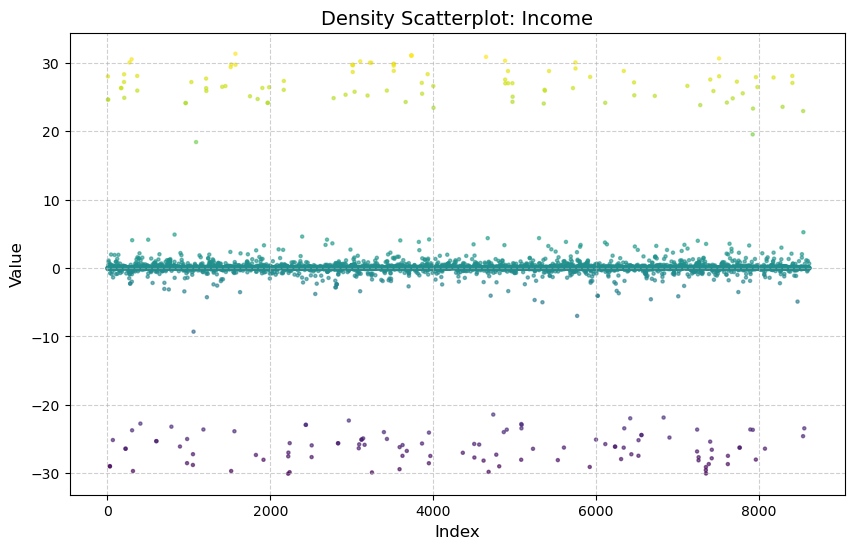

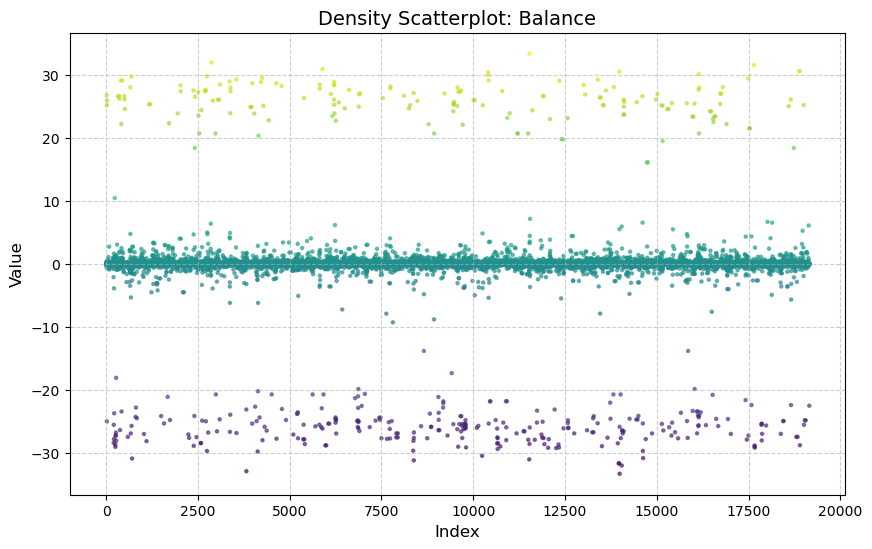

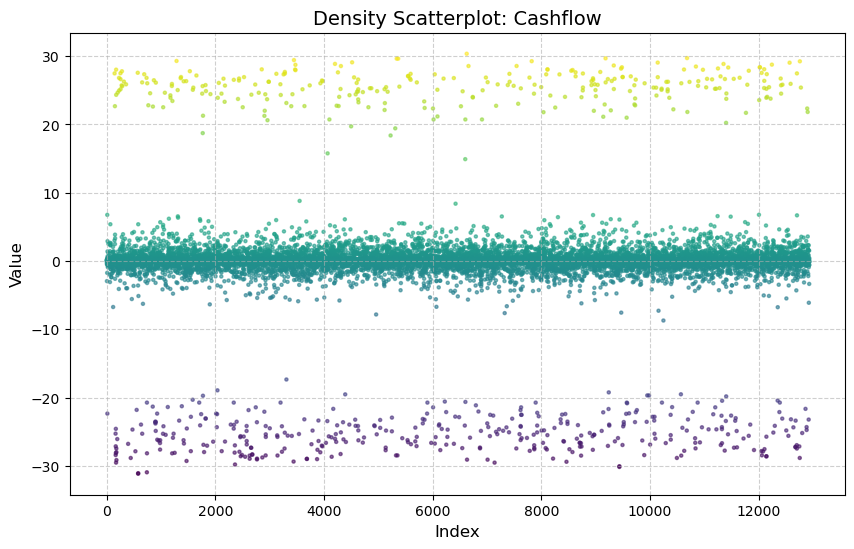

In [21]:
def outlier_check_1(df, title):
    # Flatten all numeric columns into one long vector
    numeric_cols = df.select_dtypes(include=["float", "int"]).columns
    values = df[numeric_cols].values.flatten()
    values = values[~np.isnan(values)]  # drop NaNs

    # Scatter vs. index, colored by density
    plt.figure(figsize=(10, 6))
    sns.kdeplot(values, fill=True, color="lightblue", alpha=0.3, linewidth=0)  # background density
    plt.scatter(range(len(values)), values, 
                c=values, cmap="viridis", s=5, alpha=0.6)

    plt.title(f"Density Scatterplot: {title}", fontsize=14)
    plt.xlabel("Index", fontsize=12)
    plt.ylabel("Value", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

# Call for each of your cleaned DataFrames
outlier_check_1(income_post_nans_overlapped_sorted, "Income")
outlier_check_1(balance_post_nans_overlapped_sorted, "Balance")
outlier_check_1(cashflow_post_nans_overlapped_sorted, "Cashflow")

#demonstrates the necessity for addressing outlier concerns 
# ONLY PURPOSE OF. THIS IS TO CONFIRM WE HAVE SERIOUS OUTLIERS THAT NEED TO BE ADDRESSED

In [22]:
def drop_high_zero_columns(df, threshold=0.01):
    """
    Drops columns with more than `threshold` proportion of zero values,
    and reports how many columns were dropped.
    """
    original_col_count = df.shape[1]

    zero_proportion = (df == 0).sum() / len(df)
    cols_to_drop = zero_proportion[zero_proportion > threshold].index

    df = df.drop(columns=cols_to_drop)
    new_col_count = df.shape[1]

    print(f"Columns before: {original_col_count}")
    print(f"Columns dropped: {len(cols_to_drop)} (>{threshold*100:.1f}% zeros)")
    print(f"Columns after: {new_col_count}")

    return df

Columns before: 21
Columns dropped: 14 (>1.0% zeros)
Columns after: 7
Columns before: 43
Columns dropped: 27 (>0.5% zeros)
Columns after: 16
Columns before: 30
Columns dropped: 21 (>0.5% zeros)
Columns after: 9


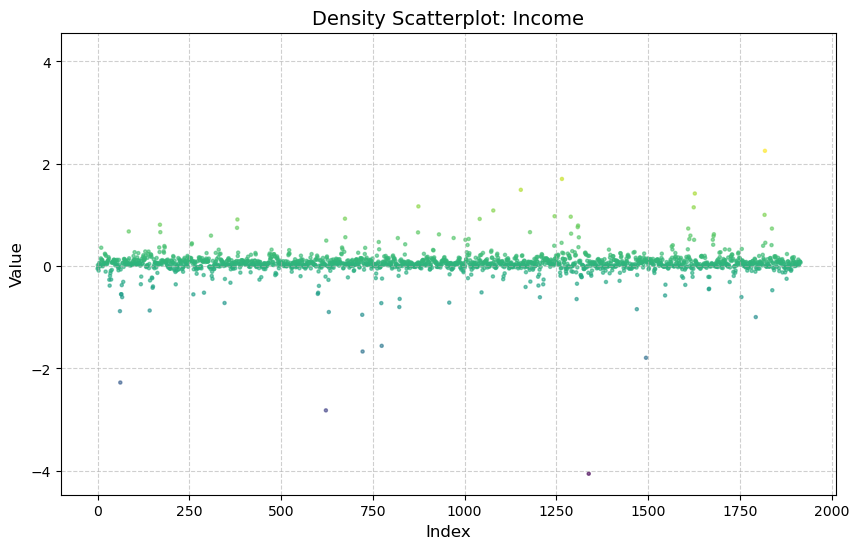

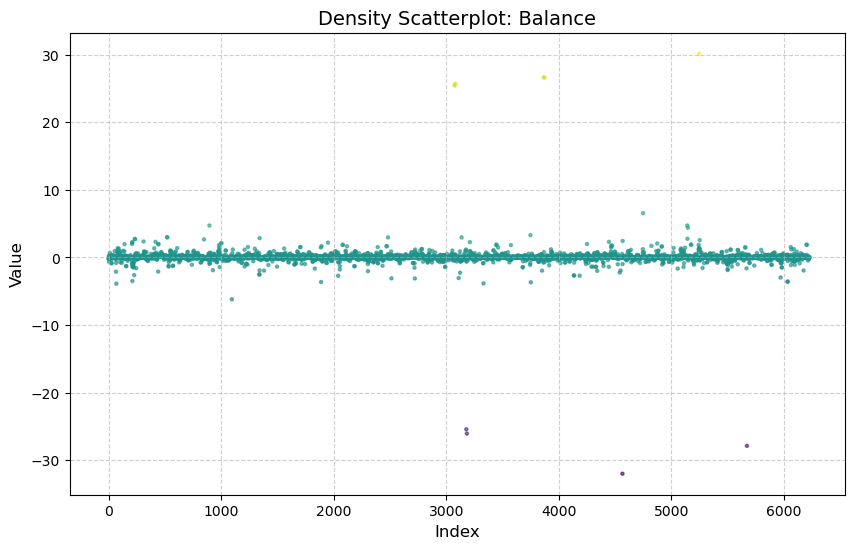

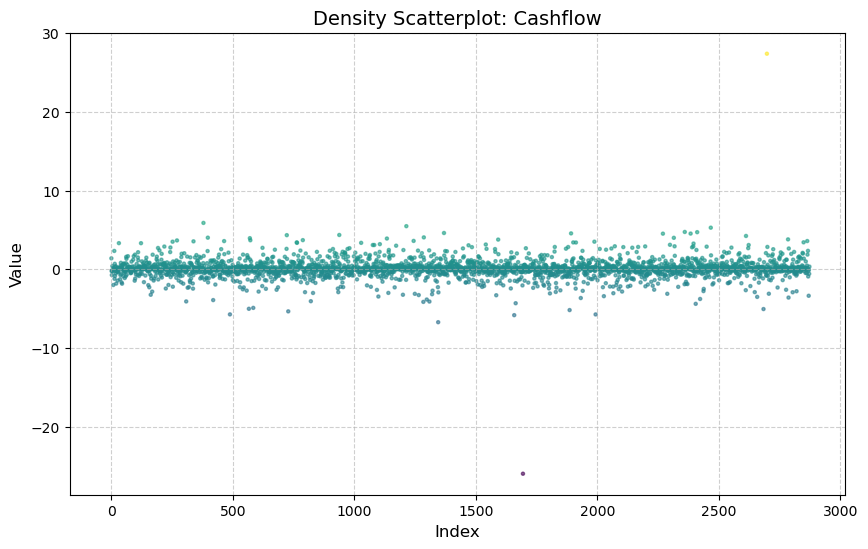

(479, 7)
(479, 16)
(479, 9)


In [23]:
income_after_feature_drop = drop_high_zero_columns(income_post_nans_overlapped_sorted, threshold=0.01)
balance_after_feature_drop = drop_high_zero_columns(balance_post_nans_overlapped_sorted, threshold=0.005)
cashflow_after_feature_drop = drop_high_zero_columns(cashflow_post_nans_overlapped_sorted, threshold=0.005)

# Call for each of your cleaned DataFrames
outlier_check_1(income_after_feature_drop, "Income")
outlier_check_1(balance_after_feature_drop, "Balance")
outlier_check_1(cashflow_after_feature_drop, "Cashflow")

print(income_after_feature_drop.shape)
print(balance_after_feature_drop.shape)
print(cashflow_after_feature_drop.shape)

In [24]:
def drop_outlier_rows(df, threshold=10):
    """
    Drops rows where ANY numeric column has a value greater than `threshold`
    or less than `-threshold`. Prints how many rows remain afterward.

    Parameters
    ----------
    df : pd.DataFrame
        The dataframe to filter.
    threshold : float
        Absolute cutoff for detecting outliers (e.g., 10 retains rows within [-10, 10]).
    """
    original_row_count = df.shape[0]

    # Identify numeric columns
    numeric_cols = df.select_dtypes(include=["number"]).columns

    # Create mask: keep rows where all numeric values are within [-threshold, threshold]
    mask = (df[numeric_cols].abs() <= threshold).all(axis=1)
    df_filtered = df[mask].copy()

    new_row_count = df_filtered.shape[0]
    dropped_rows = original_row_count - new_row_count

    print(f"Rows before: {original_row_count}")
    print(f"Rows dropped: {dropped_rows} (>|{threshold}| in any numeric column)")
    print(f"Rows after: {new_row_count}")

    return df_filtered

Rows before: 479
Rows dropped: 0 (>|10| in any numeric column)
Rows after: 479
Rows before: 479
Rows dropped: 6 (>|10| in any numeric column)
Rows after: 473
Rows before: 479
Rows dropped: 2 (>|10| in any numeric column)
Rows after: 477


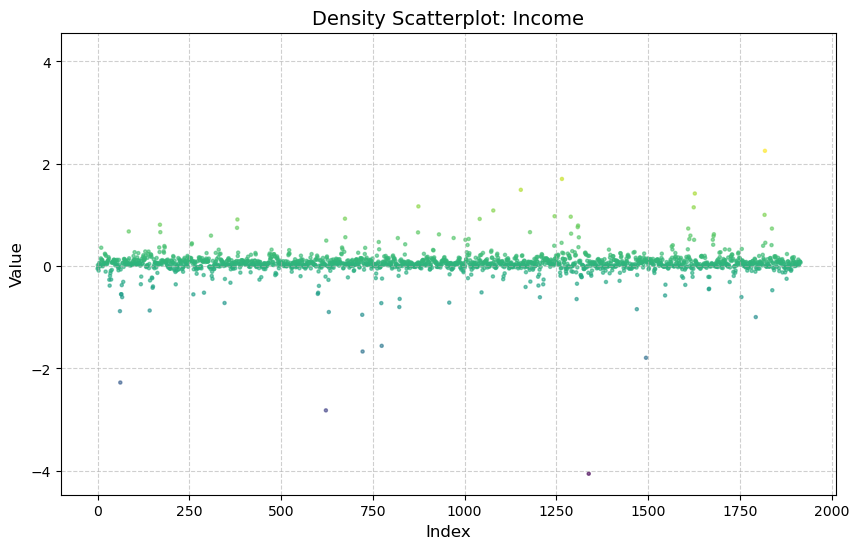

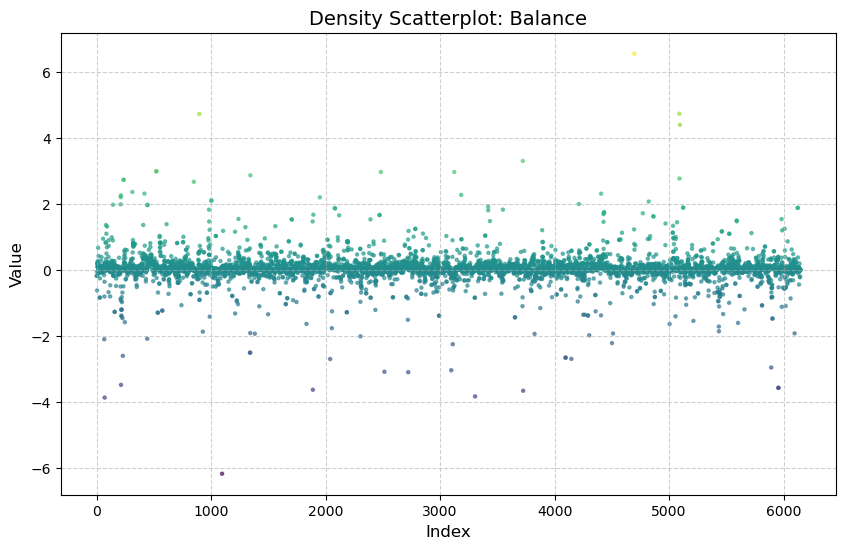

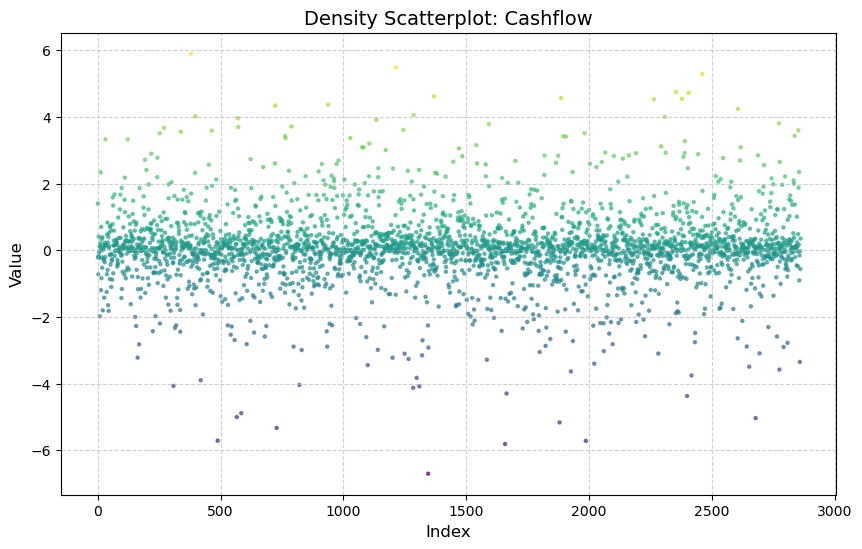

(479, 7)
(473, 16)
(477, 9)


(480, 5)

In [25]:
# --- Drop rows with extreme outliers (values beyond ±10) ---
income_after_outlier_drop   = drop_outlier_rows(income_after_feature_drop, threshold=10)
balance_after_outlier_drop  = drop_outlier_rows(balance_after_feature_drop, threshold=10)
cashflow_after_outlier_drop = drop_outlier_rows(cashflow_after_feature_drop, threshold=10)

outlier_check_1(income_after_outlier_drop, "Income")
outlier_check_1(balance_after_outlier_drop, "Balance")
outlier_check_1(cashflow_after_outlier_drop, "Cashflow")


print(income_after_outlier_drop.shape)
print(balance_after_outlier_drop.shape)
print(cashflow_after_outlier_drop.shape)
pe_data_sorted.shape

# Align df

In [26]:
def align_dfs_on_symbol_date(
    dfs,
    symbol_col="symbol",
    date_col="date",
    key_col="symbol_date",
    drop_duplicates=True,
    verbose=True
):
    """
    Align multiple DataFrames on the intersection of (symbol, date) pairs.

    Parameters
    ----------
    dfs : dict or list
        If dict: mapping name -> DataFrame. 
        If list: list of DataFrames (names will be auto-generated).
    symbol_col : str
        Column name holding the ticker/symbol.
    date_col : str
        Column name holding the date.
    key_col : str
        Name to use for the composite key column.
    drop_duplicates : bool
        If True, drop duplicate key values in each DataFrame (keep first).
    verbose : bool
        Print progress and shapes.

    Returns
    -------
    aligned : dict
        Mapping name -> aligned DataFrame (index set to key_col, but also keeps it as a column).
    common_keys : list
        Sorted list of common key strings present in every DataFrame.

    Raises
    ------
    ValueError if no common keys are found or if required columns are missing.
    """

    # Normalize input to a dict
    if isinstance(dfs, dict):
        df_map = dict(dfs)
    else:
        df_map = {f"df_{i}": df for i, df in enumerate(dfs, 1)}

    # --- 1. Ensure required columns exist and build standardized key strings ---
    for name, df in df_map.items():
        if symbol_col not in df.columns or date_col not in df.columns:
            raise ValueError(f"{name} is missing required columns '{symbol_col}' or '{date_col}'")

        df = df.copy()
        df[key_col] = df[symbol_col].astype(str) + "_" + df[date_col].astype(str)

        if drop_duplicates:
            dup_count = df[key_col].duplicated().sum()
            if dup_count and verbose:
                print(f"{name}: dropping {dup_count} duplicate {key_col} rows (keeping first)")
            df = df[~df[key_col].duplicated(keep="first")]

        df_map[name] = df

    # --- 2. Compute intersection of keys ---
    key_sets = [set(df[key_col]) for df in df_map.values()]
    common = set.intersection(*key_sets) if key_sets else set()

    if not common:
        raise ValueError("No common symbol_date keys found across all DataFrames.")

    common_sorted = sorted(common)  # stable order

    # --- 3. Filter each df to the common keys and align them ---
    aligned = {}
    if verbose:
        print(f"\nCommon observation count: {len(common_sorted)}")

    for name, df in df_map.items():
        before = df.shape[0]
        df_f = df[df[key_col].isin(common)].copy()
        df_f = df_f.set_index(key_col).loc[common_sorted].reset_index()  # <-- keeps symbol_date as column
        after = df_f.shape[0]
        aligned[name] = df_f
        if verbose:
            print(f"  {name}: before={before}, after={after}")

    # --- 4. Sanity check: all have same ordering ---
    first_index = aligned[list(aligned.keys())[0]]["symbol_date"].tolist()
    for name, df in aligned.items():
        assert df["symbol_date"].tolist() == first_index, f"{name} misaligned!"

    return aligned, common_sorted


In [27]:
dfs = {
    "income": income_after_outlier_drop,
    "balance": balance_after_outlier_drop,
    "cashflow": cashflow_after_outlier_drop,
    "pe": pe_data_sorted
}

aligned_dict, common_keys = align_dfs_on_symbol_date(dfs,
                                                     symbol_col="symbol",
                                                     date_col="date",
                                                     key_col="symbol_date",
                                                     drop_duplicates=True,
                                                     verbose=True)

# Access aligned frames:
income_aligned = aligned_dict["income"]
balance_aligned = aligned_dict["balance"]
cashflow_aligned = aligned_dict["cashflow"]
pe_aligned = aligned_dict["pe"]

# Confirm shapes are identical:
print(income_aligned.shape, balance_aligned.shape, cashflow_aligned.shape, pe_aligned.shape)


Common observation count: 471
  income: before=479, after=471
  balance: before=473, after=471
  cashflow: before=477, after=471
  pe: before=480, after=471
(471, 7) (471, 16) (471, 9) (471, 5)


In [28]:
def standardize_as_a_check(df, name="df"):
    
    id_cols = [c for c in df.columns if c.lower() in ["symbol", "date", "symbol_date"]]
    feature_cols = [c for c in df.columns if c not in id_cols]

    numeric_cols = [c for c in feature_cols if np.issubdtype(df[c].dtype, np.number)]

    scaler = StandardScaler()
    df_standardized = df.copy()
    df_standardized[numeric_cols] = scaler.fit_transform(df[numeric_cols])

    print(f"{name} standardized: {len(numeric_cols)} columns scaled | shape = {df_standardized.shape}")
    return df_standardized, scaler

In [29]:
income_after_outlier_drop_standardized, income_scaler = standardize_as_a_check(
    income_aligned, 
    name="income_after_outlier_drop"
)

balance_after_outlier_drop_standardized, balance_scaler = standardize_as_a_check(
    balance_aligned, 
    name="balance_after_outlier_drop"
)

cashflow_after_outlier_drop_standardized, cashflow_scaler = standardize_as_a_check(
    cashflow_aligned, 
    name="cashflow_after_outlier_drop"
)

income_after_outlier_drop standardized: 4 columns scaled | shape = (471, 7)
balance_after_outlier_drop standardized: 13 columns scaled | shape = (471, 16)
cashflow_after_outlier_drop standardized: 6 columns scaled | shape = (471, 9)


In [30]:
# Example DataFrames
dfs_to_save = {
    "income_after_outlier_drop_standardized": income_after_outlier_drop_standardized,
    "balance_after_outlier_drop_standardized": balance_after_outlier_drop_standardized,
    "cashflow_after_outlier_drop_standardized": cashflow_after_outlier_drop_standardized,
    "pe_aligned": pe_aligned,
}

# Option 1: Save as pickle
for name, df in dfs_to_save.items():
    df.to_pickle(f"{name}.pkl")

# univariate regression

***you can't regress against the pe for the same period as the financial of that period (information leakage)... the price in that period wsas determined by the previous or two period ago financial statements ect... any 
security that isn't trending, and is ranged bound at all will look like there is a tiny R^2

***can't use income statement items like operating income to predict net income (Mechanical endogeneity) 

***The regression is reverse-engineering the information set, not simulating it. Given your stated goal — “what the market is willing to pay for growth / structure” — this is actually a necessary intermediate step. It helps you: identify which accounting blocks matter at all, justify dimensionality reduction (latent factors), decide what to residualize vs keep, avoid wasting effort modeling irrelevant statements. This is feature relevance, not signal purity.

In [31]:
def run_statement_univariate(statement_df, pe_data_sorted, label="", plot=False):
    # Merge on all three identifier columns to preserve them
    merged = statement_df.merge(
        pe_data_sorted, 
        on=["symbol", "date", "symbol_date"], 
        how="inner"
    )

    X = merged.select_dtypes(include=["number"]).drop(columns=["log_PE"])
    y = merged["log_PE"]

    results = []
    for col in X.columns:
        X_var = sm.add_constant(X[col])
        model = sm.OLS(y, X_var, missing="drop").fit()
        residuals = model.resid
        fitted = model.fittedvalues


        results.append({
            "feature": col,
            "coef": model.params[col],
            "t_value": model.tvalues[col],
            "p_value": model.pvalues[col],
            "r2": model.rsquared,
            "reject_null": model.pvalues[col] < 0.05
        })

    results_df = pd.DataFrame(results).sort_values(by="p_value")
    return merged, results_df


In [32]:
# Run diagnostics separately for each statement
merged_income, uni_results_income = run_statement_univariate(income_after_outlier_drop_standardized, pe_aligned, label="Income", plot=False)
merged_balance, uni_results_balance = run_statement_univariate(balance_after_outlier_drop_standardized, pe_aligned, label="Balance", plot=False)
merged_cashflow, uni_results_cashflow = run_statement_univariate(cashflow_after_outlier_drop_standardized, pe_aligned, label="Cashflow", plot=False)

/var/folders/3v/cffbrkr510z708th2gtn8s600000gn/T/ipykernel_27692/1971874783.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


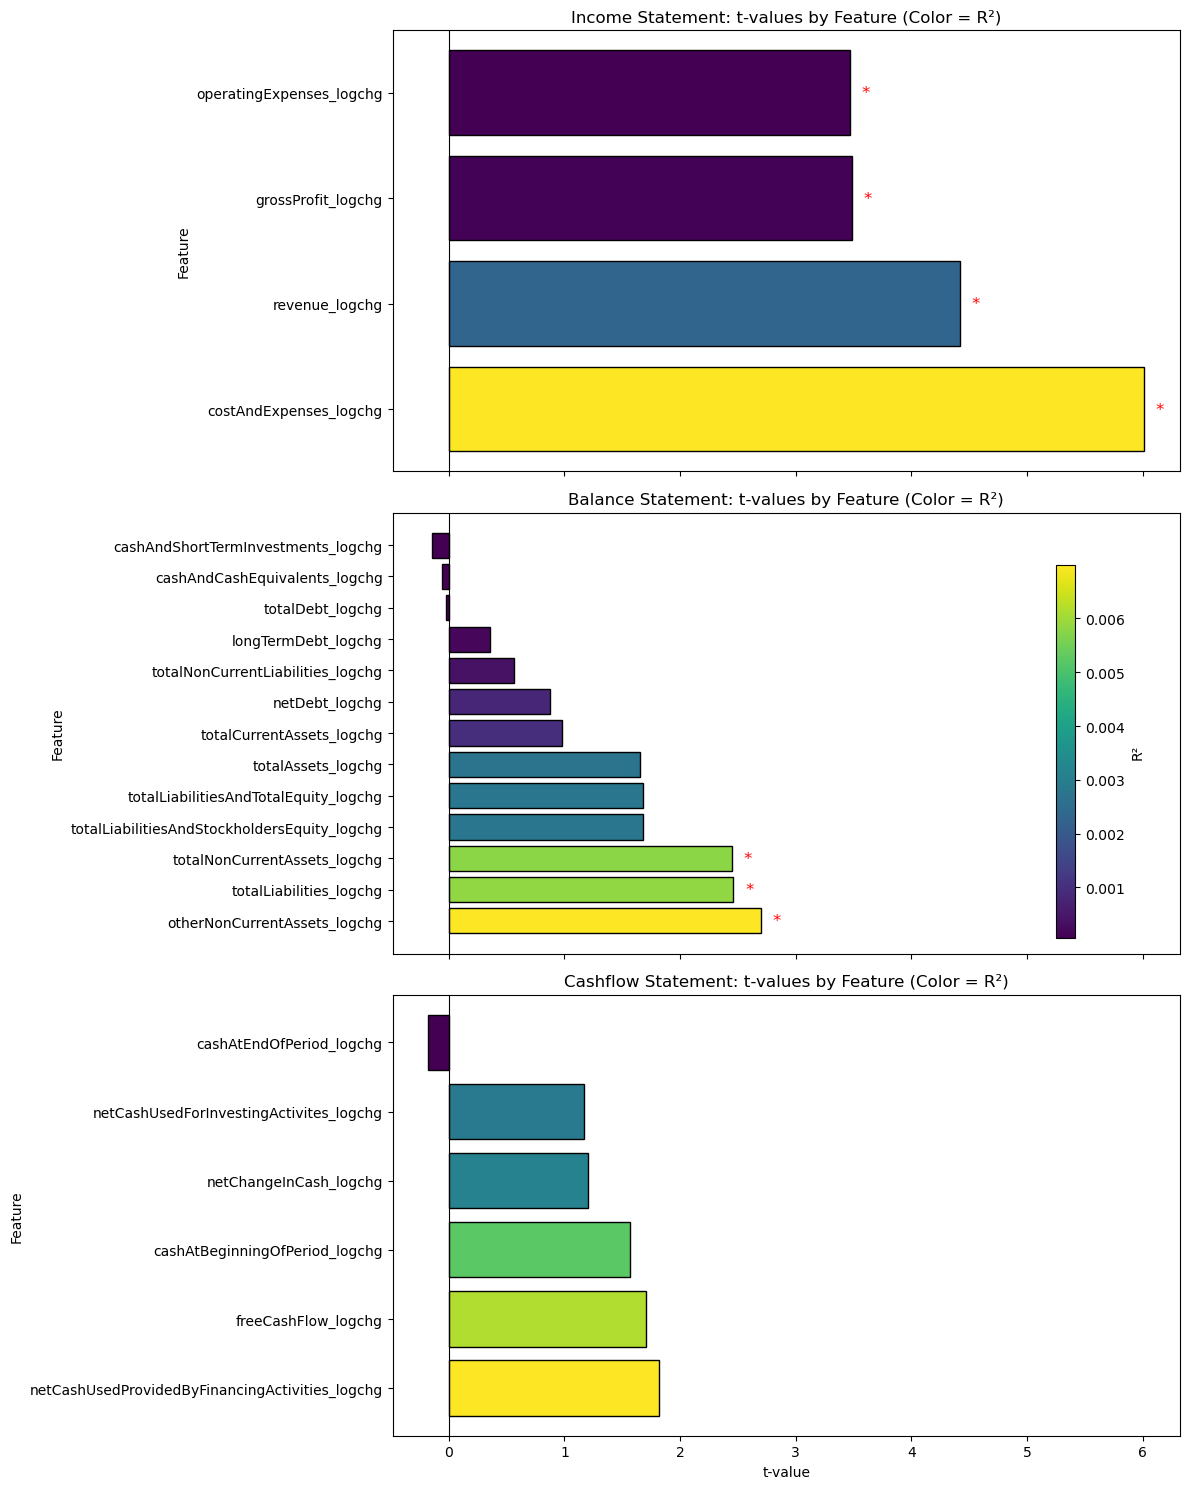

In [33]:
# Combine for convenience, but we’ll split by statement type
plot_df = pd.concat([
    uni_results_income.assign(statement_type='Income'),
    uni_results_balance.assign(statement_type='Balance'),
    uni_results_cashflow.assign(statement_type='Cashflow')
], ignore_index=True)

statement_order = ['Income', 'Balance', 'Cashflow']
n_statements = len(statement_order)

# Create subplots (one per statement type)
fig, axes = plt.subplots(n_statements, 1, figsize=(12, 5*n_statements), sharex=True)

for i, statement in enumerate(statement_order):
    ax = axes[i]
    
    # Subset for this statement
    df = plot_df[plot_df['statement_type'] == statement].copy()
    
    # Sort by absolute t-value descending
    df = df.sort_values('t_value', ascending=False).reset_index(drop=True)
    
    # Normalize r² for color mapping
    norm = mpl.colors.Normalize(vmin=df['r2'].min(), vmax=df['r2'].max())
    cmap = mpl.cm.viridis
    colors = [cmap(norm(val)) for val in df['r2']]
    
    # Y positions
    y_pos = range(len(df))
    
    # Horizontal bar chart
    ax.barh(y=y_pos, width=df['t_value'], color=colors, edgecolor='black')
    
    # Highlight significant features
    for idx, row in enumerate(df.itertuples()):
        if row.reject_null:
            ax.text(
                x=row.t_value + (0.1 if row.t_value>0 else -0.1),
                y=idx,
                s='*',
                va='center',
                ha='left' if row.t_value>0 else 'right',
                color='red',
                fontsize=12
            )
    
    # Y-axis labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df['feature'], fontsize=10)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_ylabel('Feature')
    ax.set_title(f'{statement} Statement: t-values by Feature (Color = R²)')

# Shared x-label
axes[-1].set_xlabel('t-value')

# Add a single colorbar
scalar_map = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
scalar_map.set_array([])
cbar = fig.colorbar(scalar_map, ax=axes, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('R²')


plt.tight_layout()
plt.show()


In [34]:
def select_significant_features(statement_df, uni_results, 
                                t_threshold=1.2, r2_threshold=0.005, p_threshold=0.1, 
                                label=""):
    """
    Select significant features from a financial statement dataframe
    based on univariate regression results. 
    Returns only the subset of statement_df with those features.
    """
    # Filter by thresholds
    signif = uni_results[
        (uni_results["t_value"].abs() > t_threshold) &
        (uni_results["r2"] > r2_threshold) &
        (uni_results["p_value"] < p_threshold)
    ]

    features = signif["feature"].tolist()
    
    # Only use statement data — no merge
    selected = statement_df[["symbol", "date", "symbol_date"] + features]

    if label:
        total_features = len(uni_results)
        n_selected = len(features)
        pct = (n_selected / total_features * 100) if total_features > 0 else 0
        print(f"{label.title()}: {n_selected}/{total_features} features selected ({pct:.1f}%)")

    return selected

In [35]:
# Select significant features from each statement type
selected_income = select_significant_features(
    merged_income, uni_results_income, label="Income"
)

selected_balance = select_significant_features(
    merged_balance, uni_results_balance, label="Balance"
)

selected_cashflow = select_significant_features(
    merged_cashflow, uni_results_cashflow, label="Cashflow"
)

print(selected_income.shape)
print(selected_balance.shape)
print(selected_cashflow.shape)

print(selected_income.columns.tolist)
print(selected_balance.columns.tolist)
print(selected_cashflow.columns.tolist)

Income: 4/4 features selected (100.0%)
Balance: 6/13 features selected (46.2%)
Cashflow: 2/6 features selected (33.3%)
(471, 7)
(471, 9)
(471, 5)
<bound method IndexOpsMixin.tolist of Index(['symbol', 'date', 'symbol_date', 'costAndExpenses_logchg',
       'revenue_logchg', 'grossProfit_logchg', 'operatingExpenses_logchg'],
      dtype='object')>
<bound method IndexOpsMixin.tolist of Index(['symbol', 'date', 'symbol_date', 'otherNonCurrentAssets_logchg',
       'totalLiabilities_logchg', 'totalNonCurrentAssets_logchg',
       'totalLiabilitiesAndStockholdersEquity_logchg',
       'totalLiabilitiesAndTotalEquity_logchg', 'totalAssets_logchg'],
      dtype='object')>
<bound method IndexOpsMixin.tolist of Index(['symbol', 'date', 'symbol_date',
       'netCashUsedProvidedByFinancingActivities_logchg',
       'freeCashFlow_logchg'],
      dtype='object')>


In [36]:
def combine_selected_features(selected_dfs, labels=None, add_prefix=True):
    """
    Combine multiple selected feature DataFrames (e.g., income, balance, cashflow)
    into one aligned DataFrame suitable for PCA.

    Returns
    -------
    combined_df : pd.DataFrame
        Merged DataFrame with identifiers and all features aligned.
    """
    if labels is None:
        labels = [f"df{i+1}" for i in range(len(selected_dfs))]

    dfs_prefixed = []
    for df, label in zip(selected_dfs, labels):
        id_cols = ["symbol", "date", "symbol_date"]
        feature_cols = [c for c in df.columns if c not in id_cols]
        df_copy = df.copy()
        if add_prefix:
            df_copy = df_copy.rename(columns={c: f"{label}_{c}" for c in feature_cols})
        dfs_prefixed.append(df_copy)

    # Merge all on common keys
    combined_df = dfs_prefixed[0]
    for df in dfs_prefixed[1:]:
        combined_df = combined_df.merge(df, on=["symbol", "date", "symbol_date"], how="inner")

    return combined_df


In [37]:
combined_selected_line_items = combine_selected_features(
    [selected_income, selected_balance, selected_cashflow],
    labels=["income", "balance", "cashflow"],
    add_prefix=True
)

print(combined_selected_line_items.shape)


(471, 15)


# PCA and Regression prep

In [38]:
def run_pca(df, n_components=None, prefix="PC"):
    """
    Run PCA on the numeric feature columns of a dataframe.
    Returns a separate dataframe containing only the PCA components,
    plus 'symbol' and 'date' as identifiers.

    Returns
    -------
    pca_components_df : pd.DataFrame
        Dataframe with symbol, date, and PCA components.
    pca_model : PCA object
        Fitted PCA object.
    """
    id_cols = ["symbol", "date", "symbol_date"]
    feature_cols = [c for c in df.columns if c not in id_cols]

    X = df[feature_cols].fillna(0)

    if n_components is None:
        n_components = min(len(feature_cols), len(df))

    pca = PCA(n_components=n_components)
    components = pca.fit_transform(X)

    comp_cols = [f"{prefix}{i+1}" for i in range(n_components)]
    pca_df = pd.DataFrame(components, columns=comp_cols, index=df.index)

    # Return only symbol/date/symbol_date and components
    pca_components_df = pd.concat([df[id_cols], pca_df], axis=1)

    return pca_components_df, pca


In [39]:
# Income statement PCA
income_df_pca, income_pca_model = run_pca(
    selected_income,        
    n_components=3,
    prefix="income_"
)

# Balance sheet PCA
balance_df_pca, balance_pca_model = run_pca(
    selected_balance,
    n_components=3,
    prefix="balance_"
)

# Cash flow PCA
cashflow_df_pca, cashflow_pca_model = run_pca(
    selected_cashflow,
    n_components=2,
    prefix="cashflow_"
)

In [40]:
def combine_pca_dfs(income_df_pca, balance_df_pca, cashflow_df_pca):

    # Identify ID columns and feature columns
    id_cols = ["symbol", "date", "symbol_date"]

    # Keep IDs from the first dataframe (should be identical across all)
    combined_pca_df = income_df_pca[id_cols].copy()

    # Concatenate numeric PCA features from all three
    combined_features = pd.concat([
        income_df_pca.drop(columns=id_cols),
        balance_df_pca.drop(columns=id_cols),
        cashflow_df_pca.drop(columns=id_cols)
    ], axis=1)

    # Combine identifiers with features
    combined_pca_df = pd.concat([combined_pca_df, combined_features], axis=1)

    return combined_pca_df

In [41]:
combined_pca_df = combine_pca_dfs(
    income_df_pca,
    balance_df_pca,
    cashflow_df_pca
)


print(income_df_pca.columns)
print(balance_df_pca.columns)
print(cashflow_df_pca.columns)
print(combined_pca_df.columns)

print(income_df_pca.shape)
print(balance_df_pca.shape)
print(cashflow_df_pca.shape) 
print(combined_pca_df.shape)

Index(['symbol', 'date', 'symbol_date', 'income_1', 'income_2', 'income_3'], dtype='object')
Index(['symbol', 'date', 'symbol_date', 'balance_1', 'balance_2', 'balance_3'], dtype='object')
Index(['symbol', 'date', 'symbol_date', 'cashflow_1', 'cashflow_2'], dtype='object')
Index(['symbol', 'date', 'symbol_date', 'income_1', 'income_2', 'income_3',
       'balance_1', 'balance_2', 'balance_3', 'cashflow_1', 'cashflow_2'],
      dtype='object')
(471, 6)
(471, 6)
(471, 5)
(471, 11)


# Run regressions and output

In [42]:
def regress_log_pe_on_pca(combined_df, pe_data_sorted, log_pe_col="log_PE"):
    """
    Run a multivariable linear regression using PCA components (already combined in `combined_df`)
    as independent variables, and the precomputed log_PE from `pe_data_sorted` as the dependent variable.

    Assumes both dataframes are already aligned on index.

    Returns
    -------
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        Fitted OLS model.
    reg_df : pd.DataFrame
        DataFrame containing all features and the dependent variable (used in regression).
    """

    # Build regression dataframe
    reg_df = combined_df.copy()
    reg_df[log_pe_col] = pe_data_sorted[log_pe_col]

    # Replace inf/-inf with NaN and drop missing
    reg_df = reg_df.replace([np.inf, -np.inf], np.nan).dropna()

    # Split dependent and independent variables
    y = reg_df[log_pe_col]
    X = reg_df.drop(columns=[log_pe_col]).select_dtypes(include=["number"])

    # Add constant
    X_const = sm.add_constant(X)

    # Fit regression
    model = sm.OLS(y, X_const).fit()

    print(model.summary())
    return model, reg_df

In [43]:
model, reg_df = regress_log_pe_on_pca(
    combined_pca_df,   
    pe_data_sorted,
    log_pe_col="log_PE")

                            OLS Regression Results                            
Dep. Variable:                 log_PE   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     1.597
Date:                Wed, 04 Mar 2026   Prob (F-statistic):              0.123
Time:                        11:04:11   Log-Likelihood:                -541.78
No. Observations:                 471   AIC:                             1102.
Df Residuals:                     462   BIC:                             1139.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.3018      0.036     92.842      0.0

This regression provides an upper bound on how much of the cross-sectional variation in contemporaneous valuation can be linearly associated with these accounting features. 
the features are not jointly significant (they're mostly explaining the. same variance)

In [44]:
model, reg_df = regress_log_pe_on_pca(
    combined_selected_line_items,   # your already concatenated PCA dataframe
    pe_data_sorted,
    log_pe_col="log_PE"
)

                            OLS Regression Results                            
Dep. Variable:                 log_PE   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1.267
Date:                Wed, 04 Mar 2026   Prob (F-statistic):              0.240
Time:                        11:04:11   Log-Likelihood:                -541.16
No. Observations:                 471   AIC:                             1106.
Df Residuals:                     459   BIC:                             1156.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                                               coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

Yes — for your stated goal, that proxy is more defensible than what you were doing before.
You are not trying to forecast growth in real time. You are trying to estimate:
How much extra P/E the market pays for an extra point of growth
That is a pricing-of-growth question, not a forecasting question.
So in that setup, using future realized growth as a stand-in for the growth the market must have been pricing is reasonable.
The key distinction
You are not asking:
“Could investors have known this at the time?”
You are asking:
“When firms later turned out to grow faster, did they already trade at higher multiples beforehand, and by how much?”
That is a valid ex-post way to estimate the market’s implicit price of growth


So yes — this is better than:
dependent variable = current log(PE)
independent variables = past log changes in fundamentals
Because that old setup says:
current valuation is explained by growth that already happened
and that is weaker than saying:
current valuation is explained by growth that subsequently materialized
if your aim is to back out the market’s growth pricing.